# IMPORTING THE REQUIRED LYBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import re
import nltk
from nltk.corpus import stopwords

# importing nltk and stopword
nltk.download('stopwords') #for stopword removal
nltk.download('wordnet') # Required for lemmatization
nltk.download('punkt')  #required for word tokenization

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS
import string


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report,roc_curve

import pickle

import warnings
warnings.filterwarnings('ignore')





[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/durgeshpatel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/durgeshpatel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/durgeshpatel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Loading The Data

In [4]:
train = pd.read_csv('train.csv')

# Basic Data Analysis

In [5]:
train.shape

(159571, 8)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [7]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [8]:
train.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
#check for the null values
train.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

# Exploratory Data Analysis

In [10]:
labels=train.iloc[:, 2:8]  #labels with their corresponding values
labels

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [11]:
label_count=train.iloc[:, 2:8].sum()  #sum at rowwise
label_count

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [12]:
#lets see labels values
rowsums = train.iloc[:, 2:8].sum(axis=1) #sum at columnwise
rowsums

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [13]:
#now filter the comment with atleast one lable and without labels
nonlabels = 0
for i,value in rowsums.items():
    if value == 0:
        nonlabels += 1


print("Total number of comments: ",len(train))
print("Number of comment without labels: ", nonlabels)
print("Total number of comments with labels: ",rowsums.sum())  #or label_count.sum()

Total number of comments:  159571
Number of comment without labels:  143346
Total number of comments with labels:  35098


In [14]:
for col in ['toxic','severe_toxic','obscene','threat','insult','identity_hate']:
    print(f'------------------------{col}-----------------------')
    display(train.loc[train[col]==1,['comment_text',col]].sample(2))

------------------------toxic-----------------------


,comment_text,toxic
111355,"A personal attack\n\nYou are a ignorant, twist...",1
57363,You are a coward and a fool.,1


------------------------severe_toxic-----------------------


,comment_text,severe_toxic
112737,fuck cocksucker titty marijuana nigger whore,1
115222,"Hey fuck you cunt bag!,you dont own wikpedia. ...",1


------------------------obscene-----------------------


...

,comment_text,threat
24616,dear omni looser stop editing my crap then die,1
51019,Jerk\nIll shwo you idiot! I will finish your l...,1


------------------------insult-----------------------


,comment_text,insult
103170,Just shut your ass NeilN dumb asshole.,1
66385,asshole\nfuck u asshole go fucking rape my penis,1


------------------------identity_hate-----------------------


,comment_text,identity_hate
86585,Thats not waht your black cocked momma said to...,1
115011,i hate you u stupid little midget,1


# Data Visualization

In [15]:
classes=['toxic', 'severe_toxic', 'obscene', 'threat' ,'insult' , 'identity_hate']
print(classes)

['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


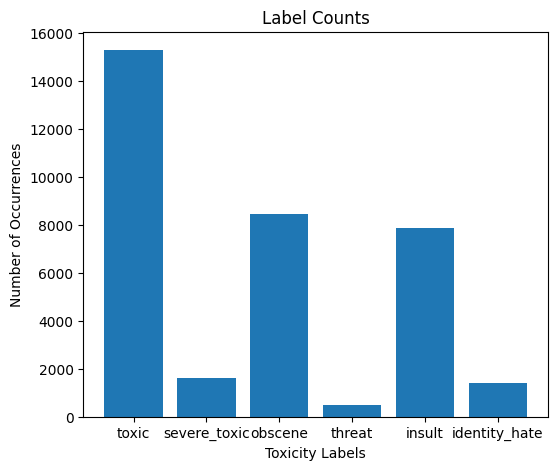

In [16]:
#let see the bar chart for each classes

# also counting the occurrences of each toxicity label
catg = train[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum()

# Create the bar chart
plt.figure(figsize=(6, 5))
plt.bar(catg.index, catg.values)
plt.xlabel("Toxicity Labels")
plt.ylabel("Number of Occurrences")
plt.title("Label Counts")
plt.show()


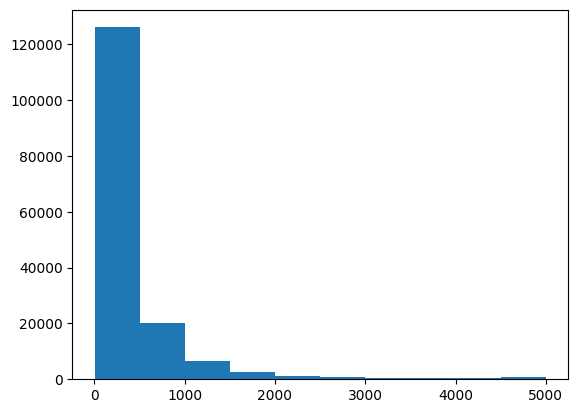

In [17]:
#length of th characters in train dataset
train['char_length'] = train['comment_text'].apply(lambda x: len(str(x)))
plt.figure()
plt.hist(train['char_length'])
plt.show()

train = train.drop('char_length',axis=1)


<Axes: title={'center': 'Correlation of features & targets'}>

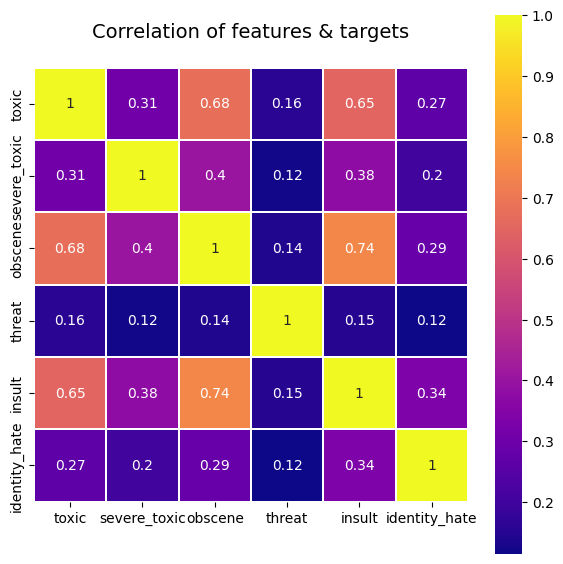

In [18]:
#Heatmap showing correlation between features nad labels
data=train[classes]
colormap = plt.cm.plasma
plt.figure(figsize=(7,7))
plt.title('Correlation of features & targets',y=1.05,size=14)
sns.heatmap(data.astype(float).corr(),linewidths=0.1,vmax=1.0,square=True,cmap=colormap,linecolor='white',annot=True)

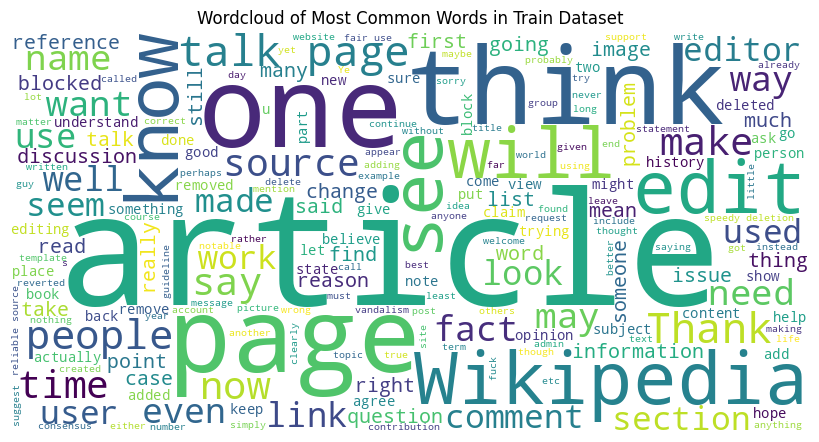

In [19]:
# wordcloud image of most common word present in tha train dataset


# Combine all text data into a single string
text = ' '.join(train['comment_text'].astype(str))

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)

# Display the generated image:
plt.figure(figsize=(8, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.title("Wordcloud of Most Common Words in Train Dataset")
plt.show()

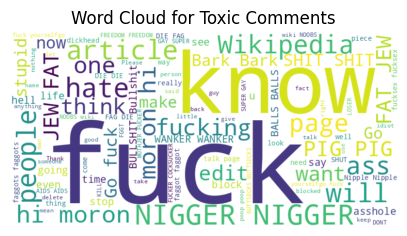

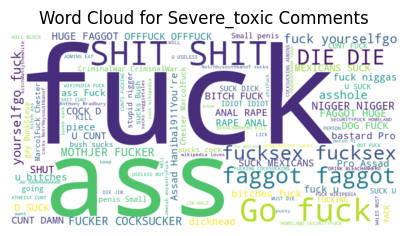

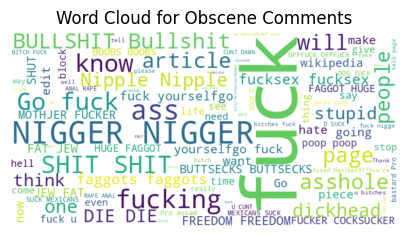

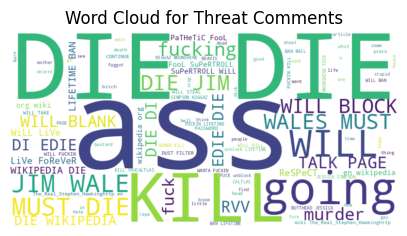

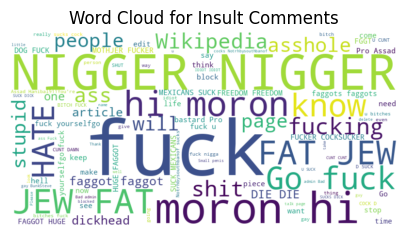

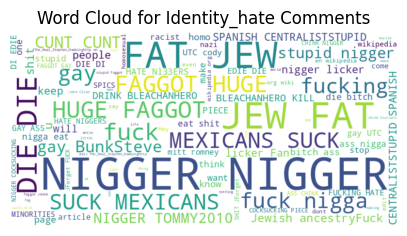

In [21]:
def plot_wordcloud(data, category_name):
    # Filter comments for the specific category
    category_comments = ' '.join(data[data[category_name] == 1]['comment_text'])
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(category_comments)
    
    # Plot word cloud
    plt.figure(figsize=(5, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {category_name.capitalize()} Comments')
    plt.show()

# Plot word clouds for each category
for category in ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']:
    plot_wordcloud(train, category)

# Data Cleaning

In [22]:
train=train.drop(columns=["id"], axis= 1)
train.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [23]:
#normal comment cleaning steps for train dataset

def clean(data, col):

    # Apply cleaning to the comment_text column
    data[col] = data[col].astype(str)  # Ensure the column is of string type
    data[col] = data[col].str.replace(r"http\S+", "")
    data[col] = data[col].str.replace(r"http", "")
    data[col] = data[col].str.replace(r"@\S+", "")
    data[col] = data[col].str.replace('https?://\S+|www\.\S+', ' social medium ')

    data[col] = data[col].str.lower()
    data[col] = data[col].str.replace("!", "i")
    data[col] = data[col].str.replace("|", "i")
    data[col] = data[col].str.replace("@", "a")
    data[col] = data[col].str.replace("$", "s")
    data[col] = data[col].str.replace("#ofc", " of fuckin course ")
    data[col] = data[col].str.replace("fggt", " faggot ")
    data[col] = data[col].str.replace("your", " your ")
    data[col] = data[col].str.replace("self", " self ")
    data[col] = data[col].str.replace("cuntbag", " cunt bag ")
    data[col] = data[col].str.replace("fartchina", " fart china ")
    data[col] = data[col].str.replace("youi", " you i ")
    data[col] = data[col].str.replace("cunti", " cunt i ")
    data[col] = data[col].str.replace("sucki", " suck i ")
    data[col] = data[col].str.replace("pagedelete", " page delete ")
    data[col] = data[col].str.replace("cuntsi", " cuntsi ")
    data[col] = data[col].str.replace("i'm", " i am ")
    data[col] = data[col].str.replace("offuck", " of fuck ")
    data[col] = data[col].str.replace("centraliststupid", " central ist stupid ")
    data[col] = data[col].str.replace("hitleri", " hitler i ")
    data[col] = data[col].str.replace("i've", " i have ")
    data[col] = data[col].str.replace("i'll", " sick ")
    data[col] = data[col].str.replace("fuck", " fuck ")
    data[col] = data[col].str.replace("f u c k", " fuck ")
    data[col] = data[col].str.replace("shit", " shit ")
    data[col] = data[col].str.replace("bunksteve", " bunk steve ")
    data[col] = data[col].str.replace('wikipedia', ' social medium ')
    data[col] = data[col].str.replace("faggot", " faggot ")
    data[col] = data[col].str.replace("delanoy", " delanoy ")
    data[col] = data[col].str.replace("jewish", " jewish ")
    data[col] = data[col].str.replace("sexsex", " sex ")
    data[col] = data[col].str.replace("allii", " all ii ")
    data[col] = data[col].str.replace("i'd", " i had ")
    data[col] = data[col].str.replace("'s", " is ")
    data[col] = data[col].str.replace("youbollocks", " you bollocks ")
    data[col] = data[col].str.replace("dick", " dick ")
    data[col] = data[col].str.replace("cuntsi", " cuntsi ")
    data[col] = data[col].str.replace("mothjer", " mother ")
    data[col] = data[col].str.replace("cuntfranks", " cunt ")
    data[col] = data[col].str.replace("ullmann", " jewish ")
    data[col] = data[col].str.replace("mr.", " mister ")
    data[col] = data[col].str.replace("aidsaids", " aids ")
    data[col] = data[col].str.replace("njgw", " nigger ")
    data[col] = data[col].str.replace("wiki", " social medium ")
    data[col] = data[col].str.replace("administrator", " admin ")
    data[col] = data[col].str.replace("gamaliel", " jewish ")
    data[col] = data[col].str.replace("rvv", " vanadalism ")
    data[col] = data[col].str.replace("admins", " admin ")
    data[col] = data[col].str.replace("pensnsnniensnsn", " penis ")
    data[col] = data[col].str.replace("pneis", " penis ")
    data[col] = data[col].str.replace("pennnis", " penis ")
    data[col] = data[col].str.replace("pov.", " point of view ")
    data[col] = data[col].str.replace("vandalising", " vandalism ")
    data[col] = data[col].str.replace("cock", " dick ")
    data[col] = data[col].str.replace("asshole", " asshole ")
    data[col] = data[col].str.replace("youi", " you ")
    data[col] = data[col].str.replace("afd", " all fucking day ")
    data[col] = data[col].str.replace("sockpuppets", " sockpuppetry ")
    data[col] = data[col].str.replace("iiprick", " iprick ")
    data[col] = data[col].str.replace("penisi", " penis ")
    data[col] = data[col].str.replace("warrior", " warrior ")
    data[col] = data[col].str.replace("loil", " laughing out insanely loud ")
    data[col] = data[col].str.replace("vandalise", " vanadalism ")
    data[col] = data[col].str.replace("helli", " helli ")
    data[col] = data[col].str.replace("lunchablesi", " lunchablesi ")
    data[col] = data[col].str.replace("special", " special ")
    data[col] = data[col].str.replace("ilol", " i lol ")

    data[col] = data[col].str.replace(r'\b[uU]\b', 'you')
    data[col] = data[col].str.replace(r"what's", "what is ")
    data[col] = data[col].str.replace(r"\'s", " is ")
    data[col] = data[col].str.replace(r"\'ve", " have ")
    data[col] = data[col].str.replace(r"can't", "cannot ")
    data[col] = data[col].str.replace(r"n't", " not ")
    data[col] = data[col].str.replace(r"i'm", "i am ")
    data[col] = data[col].str.replace(r"\'re", " are ")
    data[col] = data[col].str.replace(r"\'d", " would ")
    data[col] = data[col].str.replace(r"\'ll", " will ")
    data[col] = data[col].str.replace(r"\'scuse", " excuse ")


    data[col] = data[col].str.replace('\s+', ' ')  # will remove more than one whitespace character
    data[col] = data[col].str.replace("\n", " ") 
    data[col] = data[col].str.replace(r'(.)\1+', r'\1\1') # 2 or more characters are replaced by 2 characters

    # removing some spetial symbols
    data[col] = data[col].str.replace("[:|♣|'|§|♠|*|/|?|=|%|&|-|#|•|~|^|>|<|►|_]", '')


    return data[col] # return only the cleaned column


In [24]:
train['comment_text'] = clean(train, 'comment_text') #normal cleaning steps

In [25]:
#removing  punctuation
def remove_punctuation(text):
    
    return re.sub(r'[^\w\s]', '', text)


train['comment_text'] = train['comment_text'].apply(lambda x: remove_punctuation(x))

In [26]:
train.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation why the edits made under my userna...,0,0,0,0,0,0
1,dawwi he matches this background colour i am ...,0,0,0,0,0,0
2,hey man i am really not trying to edit war i...,0,0,0,0,0,0
3,more i cannot make any real suggestions on i...,0,0,0,0,0,0
4,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [27]:
#removing the stopwords
stop = set(stopwords.words('english'))
print(stop)
def remove_stopwords(text):

    words = [ w for w in text.split() if not w in stop]
    return ' '.join(words)

{'all', 'from', 'for', 'me', 'so', "you'd", 'each', "he's", 'aren', "doesn't", "he'd", 'its', 'not', 'ma', 's', "he'll", 'am', 'couldn', "hasn't", 'o', "weren't", 'while', 'own', "it's", 'again', 'into', 'of', 'was', "i'd", 'as', "it'd", 'weren', 'same', 'on', 'himself', 'he', 'through', 'did', 'yours', "won't", 'here', 'hadn', "she's", "we've", "i'll", "you'll", "you've", "it'll", 'under', 'in', "that'll", 'because', "aren't", 'no', 'off', 'having', 'you', 'now', 'have', 'ourselves', "they'll", 'with', 'up', 'him', 'above', 'shouldn', 'herself', 'over', "we'll", 'our', 'itself', "mustn't", 'hasn', 'has', 'her', 'isn', 'a', "she'd", 'don', "haven't", 'which', "they'd", 'y', 'will', 'there', 'yourselves', 'before', 'further', 'll', 'does', 'his', 'most', 'haven', 'during', 'at', 'them', 'it', 'who', 'm', 'do', 'but', 'wasn', "wouldn't", 'nor', 'some', 'ain', 'very', 'wouldn', 'is', 'yourself', 'when', 'against', 'more', 'both', 'mustn', 'myself', 'where', "mightn't", 'how', 'too', 'to',

In [28]:
train['comment_text'] = train['comment_text'].apply(lambda x: remove_stopwords(x))  #stopword cleaning

In [29]:
train.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation edits made username hardcore metal...,0,0,0,0,0,0
1,dawwi matches background colour seemingly stuc...,0,0,0,0,0,0
2,hey man really trying edit war guy constantly ...,0,0,0,0,0,0
3,cannot make real suggestions improvement wonde...,0,0,0,0,0,0
4,sir hero chance remember page,0,0,0,0,0,0


In [30]:
#stemming  the data
stemmer = nltk.stem.SnowballStemmer('english')


#x=stemmer.stem("running")
#print(x)

def stem_text(text):
    if isinstance(text, str):
         words = text.split()
         stem_words = [stemmer.stem(word) for word in words]
         return ' '.join(stem_words)
    return text


In [31]:
train['comment_text'] = train['comment_text'].apply(lambda x: stem_text(x))    #stemming the text
train.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explan edit made usernam hardcor metallica fan...,0,0,0,0,0,0
1,dawwi match background colour seem stuck thank...,0,0,0,0,0,0
2,hey man realli tri edit war guy constant remov...,0,0,0,0,0,0
3,cannot make real suggest improv wonder section...,0,0,0,0,0,0
4,sir hero chanc rememb page,0,0,0,0,0,0


# Splitting data into train/test

In [32]:
# the final text and the label
X = train['comment_text']
y = train[classes]
print(X)
print(y)

# Splitting the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

0         explan edit made usernam hardcor metallica fan...
1         dawwi match background colour seem stuck thank...
2         hey man realli tri edit war guy constant remov...
3         cannot make real suggest improv wonder section...
4                                sir hero chanc rememb page
                                ...                        
159566    second time ask view complet contradict covera...
159567     asham self horribl thing put talk page 128611993
159568    spitzer umm there actual articl prostitut ring...
159569    look like actual put speedi first version dele...
159570    realli think understand came idea bad right aw...
Name: comment_text, Length: 159571, dtype: object
        toxic  severe_toxic  obscene  threat  insult  identity_hate
0           0             0        0       0       0              0
1           0             0        0       0       0              0
2           0             0        0       0       0              0
3           0     

# Vectorize the data

In [33]:
# vectorization of the data using TF-IDF
tfidf = TfidfVectorizer(max_features=15000)
XTrain = tfidf.fit_transform(X_train)
XTest = tfidf.transform(X_test)

# Model training

# 1. Logistic Regression + OvsR

In [34]:
# Initializing the OneVsRest classifier with Logistic Regression
lr = OneVsRestClassifier(LogisticRegression(C=1, max_iter=1000))

# Training the model
lr.fit(XTrain, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=No

In [35]:
# Prediction on the test set for all labels
LRpred = lr.predict(XTest)
print(LRpred)

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 ...
 [0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]]


# 2. Multinomial Naive Bayes Classifier

In [36]:
mnb = OneVsRestClassifier(MultinomialNB())

mnb.fit(XTrain,y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",MultinomialNB()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [37]:
# Prediction on the test set for all labels
MNBpred = mnb.predict(XTest)
print(MNBpred)

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 ...
 [0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]]


# prediction

In [38]:
#Using LogisticRegression
comment= "stop it , or, i'll kill you."

clean=stem_text(remove_stopwords(remove_punctuation(comment)))

vec=tfidf.transform([clean])
classes=y.columns
result= lr.predict(vec)[0]


for catg, res in zip(classes, result):
    print("%14s %5s  " % (catg, res))

         toxic     1  
  severe_toxic     0  
       obscene     0  
        threat     1  
        insult     0  
 identity_hate     0  


In [39]:
#using multinomial naive bayes classifier
comment1 = "heyy nigga, come here"

vec1= tfidf.transform([comment1])
result1= mnb.predict(vec1)[0]


for catg, res in zip(classes, result1):
    print("%14s %5s  " % (catg, res))

         toxic     1  
  severe_toxic     0  
       obscene     1  
        threat     0  
        insult     1  
 identity_hate     0  


# Model Evaluation

In [40]:
lr_accuracy = accuracy_score(LRpred, y_test)
print("Accuracy of LR:",lr_accuracy)
mnb_accuracy = accuracy_score(MNBpred, y_test)
print("Accuracy of MNB: ",mnb_accuracy)


Accuracy of LR: 0.9185336048879837
Accuracy of MNB:  0.9096036346545512


In [41]:
print("Classification Report(LR):\n\n",classification_report(y_test,LRpred))

Classification Report(LR):

               precision    recall  f1-score   support

           0       0.91      0.61      0.73      3056
           1       0.58      0.26      0.36       321
           2       0.91      0.65      0.76      1715
           3       0.56      0.12      0.20        74
           4       0.81      0.52      0.63      1614
           5       0.69      0.14      0.23       294

   micro avg       0.87      0.56      0.68      7074
   macro avg       0.74      0.38      0.49      7074
weighted avg       0.86      0.56      0.67      7074
 samples avg       0.06      0.05      0.05      7074



In [42]:
print("Classification Report(MNB):\n\n",classification_report(y_test,MNBpred))

Classification Report(MNB):

               precision    recall  f1-score   support

           0       0.93      0.47      0.63      3056
           1       0.65      0.05      0.10       321
           2       0.91      0.44      0.60      1715
           3       0.00      0.00      0.00        74
           4       0.82      0.37      0.51      1614
           5       0.50      0.00      0.01       294

   micro avg       0.90      0.40      0.55      7074
   macro avg       0.64      0.22      0.31      7074
weighted avg       0.86      0.40      0.54      7074
 samples avg       0.04      0.03      0.03      7074



# To Run on app

In [41]:
pickle.dump(tfidf , open('vec.pkl', 'wb'))
pickle.dump( lr, open('mod.pkl', 'wb'))
